<a href="https://colab.research.google.com/github/Smeerz99/northstar-analytics-coursework/blob/main/notebooks/01_data_audit_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar data audit and preparation

This notebook shows the analysis for the NorthStar case study and focuses on loading the raw datasets, checking their structure, identifying data quality issues, and preparing the data for analysis in SQL, R, and MongoDB

## Loading the datasets

The first step was to load all of the datasets provided for the case study into Python using pandas. This makes it possible to inspect the structure of each file and understand how the datasets relate to each other.

In [26]:
import pandas as pd
import numpy as np

orders = pd.read_csv("/content/orders.csv")
deliveries = pd.read_csv("/content/deliveries.csv")
customers = pd.read_csv("/content/customers.csv")
drivers = pd.read_csv("/content/drivers.csv")
vehicles = pd.read_csv("/content/vehicles.csv")
hubs = pd.read_csv("/content/hubs.csv")
incidents = pd.read_csv("/content/incidents.csv")
complaints = pd.read_csv("/content/complaints.csv")
app_events = pd.read_csv("/content/app_events.csv")

datasets = {
    "orders": orders,
    "deliveries": deliveries,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "incidents": incidents,
    "complaints": complaints,
    "app_events": app_events
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    display(df.head(3))


ORDERS
Shape: (1250, 11)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0



DELIVERIES
Shape: (950, 13)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51



CUSTOMERS
Shape: (650, 9)


...

,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0



COMPLAINTS
Shape: (320, 10)


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41



APP_EVENTS
Shape: (640, 10)


,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
0,AE00001,C0488,NaN,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
1,AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
2,AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1


## Initial data inspection

After loading the files, the next step was to check the columns, data types, and missing values in each dataset. This helps identify any data quality problems that could affect later analysis.

In [27]:
for name, df in datasets.items():
    print(f"\n--- {name.upper()} ---")
    print(df.info())
    print("\nMissing values:")
    print(df.isna().sum()[df.isna().sum() > 0])


--- ORDERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1250 non-null   object 
 1   customer_id            1250 non-null   object 
 2   service_type           1250 non-null   object 
 3   order_created_at       1250 non-null   object 
 4   promised_window_hours  1250 non-null   int64  
 5   pickup_zone            1250 non-null   object 
 6   dropoff_zone           1250 non-null   object 
 7   priority_level         1250 non-null   object 
 8   order_value            1250 non-null   float64
 9   booking_channel        1225 non-null   object 
 10  special_handling_flag  1250 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 107.6+ KB
None

Missing values:
booking_channel    25
dtype: int64

--- DELIVERIES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entrie

In [28]:
for name, df in datasets.items():
    print(f"\n{name.upper()} COLUMNS:")
    print(df.columns.tolist())


ORDERS COLUMNS:
['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']

DELIVERIES COLUMNS:
['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost']

CUSTOMERS COLUMNS:
['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

DRIVERS COLUMNS:
['driver_id', 'base_zone', 'employment_type', 'years_experience', 'training_score', 'driver_rating', 'shift_preference', 'active_flag']

VEHICLES COLUMNS:
['vehicle_id', 'vehicle_type', 'assigned_zone', 'commission_date', 'battery_health_pct', 'odometer_km', 'maintenance_status', 'telematics_version']

HUBS COLUM

## Checking datetime and categorical fields

After the initial inspection, the next step was to look more closely at the date/time fields and categorical variables. This helps identify inconsistent values, formatting problems, and fields that may need to be cleaned before analysis.

In [29]:
date_columns = {
    "orders": ["order_created_at"],
    "deliveries": ["dispatch_time", "delivery_completed_at"],
    "customers": ["signup_date"],
    "vehicles": ["commission_date"],
    "incidents": ["reported_at"],
    "complaints": ["created_at"],
    "app_events": ["event_timestamp"]
}

for dataset_name, cols in date_columns.items():
    for col in cols:
        datasets[dataset_name][col] = pd.to_datetime(
            datasets[dataset_name][col],
            errors="coerce"
        )

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    for col in df.columns:
        if "date" in col or "time" in col or col.endswith("_at"):
            print(col, "->", df[col].dtype)


ORDERS
order_created_at -> datetime64[ns]

DELIVERIES
dispatch_time -> datetime64[ns]
delivery_completed_at -> datetime64[ns]

CUSTOMERS
signup_date -> datetime64[ns]

DRIVERS

VEHICLES
commission_date -> datetime64[ns]

HUBS

INCIDENTS
reported_at -> datetime64[ns]

COMPLAINTS
created_at -> datetime64[ns]

APP_EVENTS
event_timestamp -> datetime64[ns]


In [30]:
categorical_checks = {
    "orders": ["service_type", "pickup_zone", "dropoff_zone", "priority_level", "booking_channel"],
    "deliveries": ["delivery_status", "proof_of_completion_missing"],
    "customers": ["home_zone", "customer_type", "preferred_channel", "account_status"],
    "drivers": ["base_zone", "employment_type", "shift_preference", "active_flag"],
    "vehicles": ["vehicle_type", "assigned_zone", "maintenance_status", "telematics_version"],
    "hubs": ["zone", "hub_type"],
    "incidents": ["incident_type", "severity", "resolution_status"],
    "complaints": ["complaint_type", "channel", "severity", "status"],
    "app_events": ["event_type", "device_type", "zone_context", "success_flag"]
}

for dataset_name, cols in categorical_checks.items():
    print(f"\n==== {dataset_name.upper()} ====")
    df = datasets[dataset_name]
    for col in cols:
        print(f"\n{col}")
        print(df[col].value_counts(dropna=False).head(15))


==== ORDERS ====

service_type
service_type
Passenger    341
Parcel       308
Retail       297
Business     165
Medical      139
Name: count, dtype: int64

pickup_zone
pickup_zone
East         104
South        103
EAST         103
RiverSide     86
Airport       85
WEST          84
Ctr           80
CENTRAL       79
Central       79
SOUTH         78
West          71
Riverside     65
north         64
NORTH         60
AIRPORT       59
Name: count, dtype: int64

dropoff_zone
dropoff_zone
WEST         99
South        98
RiverSide    98
West         98
AIRPORT      88
Riverside    83
EAST         80
SOUTH        80
East         75
Airport      75
north        74
CENTRAL      65
NORTH        63
Central      62
Ctr          58
Name: count, dtype: int64

priority_level
priority_level
Medium      503
Low         348
High        308
Critical     91
Name: count, dtype: int64

booking_channel
booking_channel
App      635
Web      269
Phone    257
API       64
NaN       25
Name: count, dtype: int64


## Categorical standardisation and feature engineering

After loading and checking all the data, I found that some of the category values were inconsistent across the datasets. For example, some zones were written differently such as 'EAST', 'East', 'north', and 'Ctr'. This makes the analysis unreliable so they were cleaned and standardised into consistent categories. The date and time fields were also prepared so that new variables such as delivery duration could be created and any invalid records could be identified.

In [31]:
def clean_zone(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()
    x_lower = x.lower()

    mapping = {
        "north": "North",
        "south": "South",
        "east": "East",
        "west": "West",
        "central": "Central",
        "ctr": "Central",
        "riverside": "Riverside",
        "riverside ": "Riverside",
        "riverside": "Riverside",
        "riverside": "Riverside",
        "airport": "Airport"
    }

    if x_lower == "riverside":
        return "Riverside"
    if x_lower == "ctr":
        return "Central"

    return mapping.get(x_lower, x)

# create cleaned zone columns without overwriting originals
orders["pickup_zone_clean"] = orders["pickup_zone"].apply(clean_zone)
orders["dropoff_zone_clean"] = orders["dropoff_zone"].apply(clean_zone)

customers["home_zone_clean"] = customers["home_zone"].apply(clean_zone)
drivers["base_zone_clean"] = drivers["base_zone"].apply(clean_zone)
vehicles["assigned_zone_clean"] = vehicles["assigned_zone"].apply(clean_zone)
hubs["zone_clean"] = hubs["zone"].apply(clean_zone)
app_events["zone_context_clean"] = app_events["zone_context"].apply(clean_zone)

In [32]:
print("Pickup zone cleaned:")
print(orders["pickup_zone_clean"].value_counts(dropna=False))

print("\nDropoff zone cleaned:")
print(orders["dropoff_zone_clean"].value_counts(dropna=False))

print("\nHub zone cleaned:")
print(hubs["zone_clean"].value_counts(dropna=False))

Pickup zone cleaned:
pickup_zone_clean
Central      238
East         207
South        181
North        174
West         155
Riverside    151
Airport      144
Name: count, dtype: int64

Dropoff zone cleaned:
dropoff_zone_clean
West         197
North        191
Central      185
Riverside    181
South        178
Airport      163
East         155
Name: count, dtype: int64

Hub zone cleaned:
zone_clean
Central      2
South        1
North        1
East         1
West         1
Airport      1
Riverside    1
Name: count, dtype: int64


## Creating delivery duration measures

To understand delivery performance more clearly, a delivery duration variable was created using the dispatch time and completion time. This also makes it possible to identify records where the timestamps appearead to be invalid.

In [33]:
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")

deliveries["delivery_duration_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

deliveries["invalid_duration_flag"] = deliveries["delivery_duration_hours"] < 0

print(deliveries[["dispatch_time", "delivery_completed_at", "delivery_duration_hours", "invalid_duration_flag"]].head())
print("\nInvalid durations:", deliveries["invalid_duration_flag"].sum())

        dispatch_time      delivery_completed_at  delivery_duration_hours  \
0 2024-06-18 10:57:00 2024-06-19 09:05:59.904311                22.149973   
1 2025-01-11 18:45:00 2025-01-11 17:39:00.000000                -1.100000   
2 2025-06-02 20:39:00 2025-06-02 21:45:32.366770                 1.108991   
3 2024-03-08 23:31:00 2024-03-09 23:30:08.103702                23.985584   
4 2025-09-21 11:43:00 2025-09-21 15:45:34.131056                 4.042814   

   invalid_duration_flag  
0                  False  
1                   True  
2                  False  
3                  False  
4                  False  

Invalid durations: 64


## Building a joined analysis table

The datasets were then combined into one analysis table so that delivery outcomes could be examined alongside customer, driver, vehicle, and hub information. This makes it easier to explore the factors linked to delays, failures, and service quality.

In [34]:
analysis_df = deliveries.merge(
    orders[[
        "order_id", "customer_id", "service_type", "order_created_at",
        "pickup_zone_clean", "dropoff_zone_clean", "priority_level",
        "order_value", "booking_channel", "special_handling_flag"
    ]],
    on="order_id",
    how="left"
).merge(
    customers[[
        "customer_id", "age", "home_zone_clean", "customer_type",
        "loyalty_score", "app_engagement_score", "preferred_channel", "account_status"
    ]],
    on="customer_id",
    how="left"
).merge(
    drivers[[
        "driver_id", "base_zone_clean", "employment_type",
        "years_experience", "training_score", "driver_rating", "shift_preference", "active_flag"
    ]],
    on="driver_id",
    how="left"
).merge(
    vehicles[[
        "vehicle_id", "vehicle_type", "assigned_zone_clean", "battery_health_pct",
        "odometer_km", "maintenance_status", "telematics_version"
    ]],
    on="vehicle_id",
    how="left"
).merge(
    hubs[[
        "hub_id", "hub_name", "zone_clean", "hub_type", "capacity_score"
    ]],
    on="hub_id",
    how="left"
)

print("analysis_df shape:", analysis_df.shape)
analysis_df.head()

analysis_df shape: (950, 48)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,vehicle_type,assigned_zone_clean,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone_clean,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,EV,Central,78.4,29849,Active,v2.2,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,Diesel,Airport,68.6,78468,Active,v2.2,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,Diesel,East,55.9,15278,Active,v2.2,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,Hybrid,East,83.3,85635,Active,v2.1,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,EV,Riverside,94.2,210683,InRepair,v2.0,North Exchange,North,Dispatch,82


## Exploratory analysis of delivery performance

The first visual analysis looks at delivery outcomes by hub zone. This helps show whether poor performance is spread evenly across the network or concentrated in particular locations.

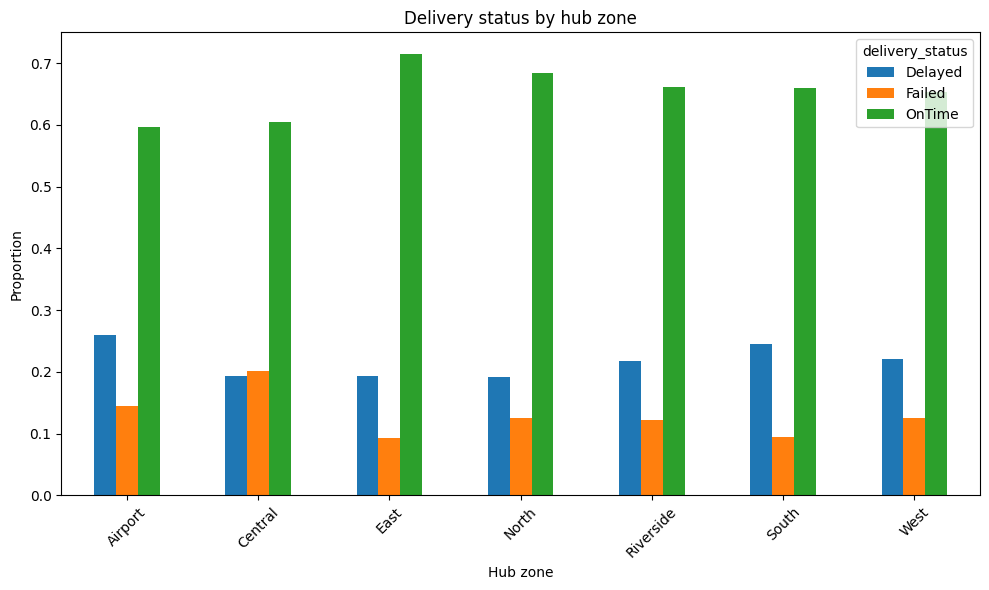

In [35]:
import matplotlib.pyplot as plt

status_by_zone = pd.crosstab(
    analysis_df["zone_clean"],
    analysis_df["delivery_status"],
    normalize="index"
)

status_by_zone.plot(kind="bar", figsize=(10, 6))
plt.title("Delivery status by hub zone")
plt.ylabel("Proportion")
plt.xlabel("Hub zone")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The chart suggests that delivery performance is not consistent across all hub zones. Some zones appear to have a higher proportion of delayed or failed deliveries, which may indicate local operational problems such as route allocation issues, hub pressure, or vehicle availability problems.

## Linking complaints and incidents to delivery outcomes

To understand service problems more clearly, complaint and incident data were summarised and linked back to the main analysis table. This makes it possible to examine whether delayed or failed deliveries are also associated with higher complaint volumes and operational incidents.

In [36]:
complaints_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    avg_resolution_days=("resolution_days", "mean"),
    total_compensation=("compensation_amount", "sum")
).reset_index()

incidents_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count"),
    avg_resolved_hours=("resolved_hours", "mean")
).reset_index()

analysis_df = analysis_df.merge(
    complaints_summary,
    on="order_id",
    how="left"
).merge(
    incidents_summary,
    on="delivery_id",
    how="left"
)

analysis_df["complaint_count"] = analysis_df["complaint_count"].fillna(0)
analysis_df["incident_count"] = analysis_df["incident_count"].fillna(0)

analysis_df[["delivery_id", "order_id", "delivery_status", "complaint_count", "incident_count"]].head()

,delivery_id,order_id,delivery_status,complaint_count,incident_count
0,DL00001,O00938,Failed,0.0,1.0
1,DL00002,O00004,OnTime,0.0,0.0
2,DL00003,O00639,OnTime,0.0,0.0
3,DL00004,O00313,Delayed,0.0,0.0
4,DL00005,O00844,OnTime,0.0,0.0


## Delivery outcomes by vehicle maintenance status

Vehicle condition may be one of the factors affecting delivery performance. This chart compares delivery outcomes across different maintenance statuses to see whether poorly maintained vehicles are linked to more delays or failures.

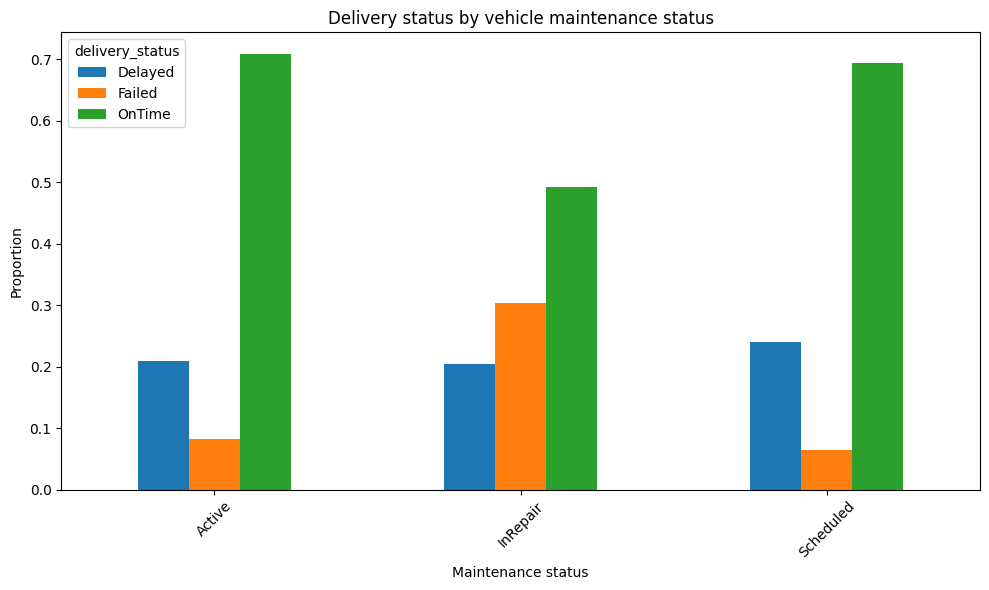

In [37]:
status_by_maintenance = pd.crosstab(
    analysis_df["maintenance_status"],
    analysis_df["delivery_status"],
    normalize="index"
)

status_by_maintenance.plot(kind="bar", figsize=(10, 6))
plt.title("Delivery status by vehicle maintenance status")
plt.ylabel("Proportion")
plt.xlabel("Maintenance status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

This chart helps show whether vehicle condition is related to operational performance. If vehicles with poorer maintenance status show a higher proportion of delayed or failed deliveries, this would support the idea that maintenance issues are contributing to service inefficiency.


## Complaints by delivery status

Customer complaints are an important indicator of service quality. This analysis compares complaint levels across delivery outcomes to see whether failed or delayed deliveries are more likely to generate customer dissatisfaction.

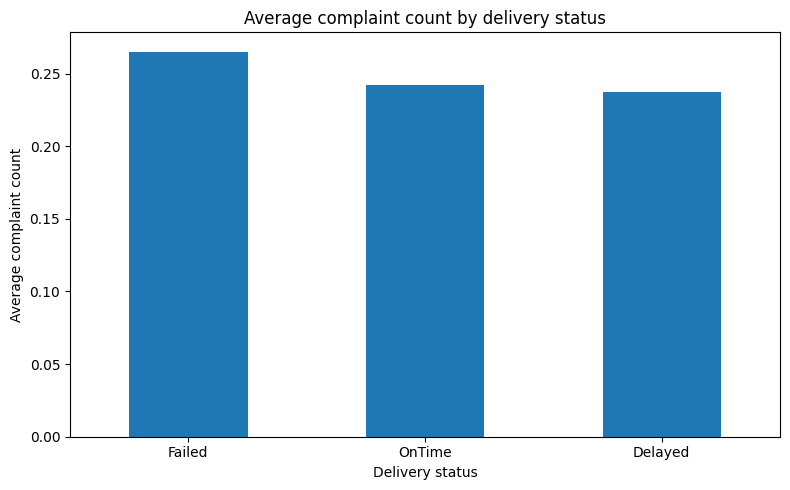

In [38]:
complaints_by_status = analysis_df.groupby("delivery_status")["complaint_count"].mean().sort_values(ascending=False)

complaints_by_status.plot(kind="bar", figsize=(8, 5))
plt.title("Average complaint count by delivery status")
plt.ylabel("Average complaint count")
plt.xlabel("Delivery status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

This result shows whether poor delivery outcomes are also connected to higher complaint levels. A higher average complaint count for delayed or failed deliveries would suggest that operational problems are directly affecting customer experience.

## Initial findings

The first stage of the analysis shows that the NorthStar datasets contain important data quality issues, including inconsistent categorical values and records that need cleaning before deeper analysis. The early visual analysis also suggests that delivery performance may vary by location and by operational factors such as vehicle condition. Linking deliveries with complaints and incidents provides a stronger basis for identifying the causes of delay, failure, and customer dissatisfaction in the later stages of the coursework.